# Training Model v4_v2 — AquaAgent Machine Learning Classifier
## Comprehensive Analysis & Visualization (Model v4_v2 + Hour)
### Dataset: `Data_Model_IoTMLCQ_2024.xlsx`
### Pelabelan berdasarkan Jurnal Ilmiah (Figure 1) & Variansi Sensor IoT Independen
- **Perbaikan Metodologi**: Train-Test Split (80:20) dilakukan **LEBIH AWAL** pada data murni 4.383 baris (bebas *data leakage*).
- **Data Uji (Test Set)**: 1.327 sampel (877 murni + 450 variansi noise independen, seed 99).
- **Data Latih (Train Set)**: 5.306 sampel (3.506 murni + 1.800 variansi noise independen, seed 42).
- **SMOTE Oversampling**: Diterapkan hanya pada data latih (`sampling_strategy=0.6`).
- **Suhu Optimal**: 25 - 32°C *(El-Sayed 1999; FAO 2023)*
- **pH Optimal**: 7.0 - 8.0 *(Lemos et al. 2018; Mengistu et al. 2020)*
- **DO Ideal**: > 5.0 mg/L *(Pedrazzani et al. 2020; Tran-Duy et al. 2012)*
- **Kekeruhan Standard**: <= 25 NTU

---
### Daftar Isi Analisis Lengkap (25 Bagian):
1. Import Library & Setup
2. Load & Eksplorasi Data (EDA)
3. Statistik Deskriptif
4. Distribusi Data Sensor
5. Distribusi Fitur Sensor (Histogram + KDE)
6. Boxplot Fitur Sensor
7. Correlation Heatmap Sensor
8. Pairplot (Scatter Matrix)
9. Pelabelan Ilmiah & Variansi Sensor IoT Independen
10. Feature Engineering v4_v2 (Cyclical Hour + Ratios)
10b. Correlation Heatmap (Setelah Feature Engineering)
11. Train-Test Split (Stratified 80:20 DAHULU - Leak-Free)
12. Training & Perbandingan 7 Model Machine Learning
13. Tabel Perbandingan Model (Ranked)
14. Visualisasi Perbandingan Metrik Evaluasi Model
14b. Radar Chart Perbandingan Model
15. Confusion Matrix Model Terbaik v4_v2 (Nilai Absolut & Persentase %)
16. Classification Report (Detail Metrik & Specificity/Sensitivity)
17. Feature Importance Analysis
18. Cross-Validation (3-Fold Stratified with Error Bars)
19. ROC Curve & AUC Score Perbandingan Semua Model
20. Precision-Recall Curve Perbandingan Semua Model
21. Learning Curve (Model Terbaik v4_v2 - Overfitting Analysis)
22. Confusion Matrix Grid — Semua Model (2x4 Subplots)
23. Ringkasan Akhir — Tabel Perbandingan Lengkap
24. Save Model & Features v4_v2 (`aquaagent_rf_v4_v2.pkl`, `rf_features_v4_v2.pkl`)
25. Sample Prediction & Interpretasi Real-Time Test


--- 
## 1. Import Library & Setup


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, learning_curve
from sklearn.ensemble import (
    RandomForestClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier,
    GradientBoostingClassifier, AdaBoostClassifier
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    precision_score, recall_score, f1_score, roc_auc_score,
    roc_curve, precision_recall_curve, average_precision_score
)
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 10
plt.rcParams['figure.dpi'] = 120

COLORS = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2']

print('Environment & Library Setup v4_v2 (Corrected Pipeline) Selesai')


Environment & Library Setup v4_v2 (Corrected Pipeline) Selesai


--- 
## 2. Load & Eksplorasi Data (EDA)


In [2]:
df_excel = pd.read_excel('Data_Model_IoTMLCQ_2024.xlsx')
temp_col = [c for c in df_excel.columns if 'Temperature (' in c][0]

df_clean = pd.DataFrame({
    'TEMP': pd.to_numeric(df_excel[temp_col], errors='coerce'),
    'DO': pd.to_numeric(df_excel['Dissolved Oxygen (mg/L)'], errors='coerce'),
    'PH': pd.to_numeric(df_excel['pH'], errors='coerce'),
    'TURBIDITY': pd.to_numeric(df_excel['Turbidity (NTU)'], errors='coerce'),
    'hour': pd.to_numeric(df_excel['hour'], errors='coerce')
}).dropna().reset_index(drop=True)

print(f'Dataset Loaded Successfully: {df_clean.shape[0]} baris, {df_clean.shape[1]} kolom')
print('\n5 Baris Pertama Data Clean:')
df_clean.head()


Dataset Loaded Successfully: 4383 baris, 5 kolom

5 Baris Pertama Data Clean:


--- 
## 3. Statistik Deskriptif


In [3]:
print('Statistik Deskriptif Dataset Initial:')
df_clean.describe().T


Statistik Deskriptif Dataset Initial:


--- 
## 4. Distribusi Data Sensor


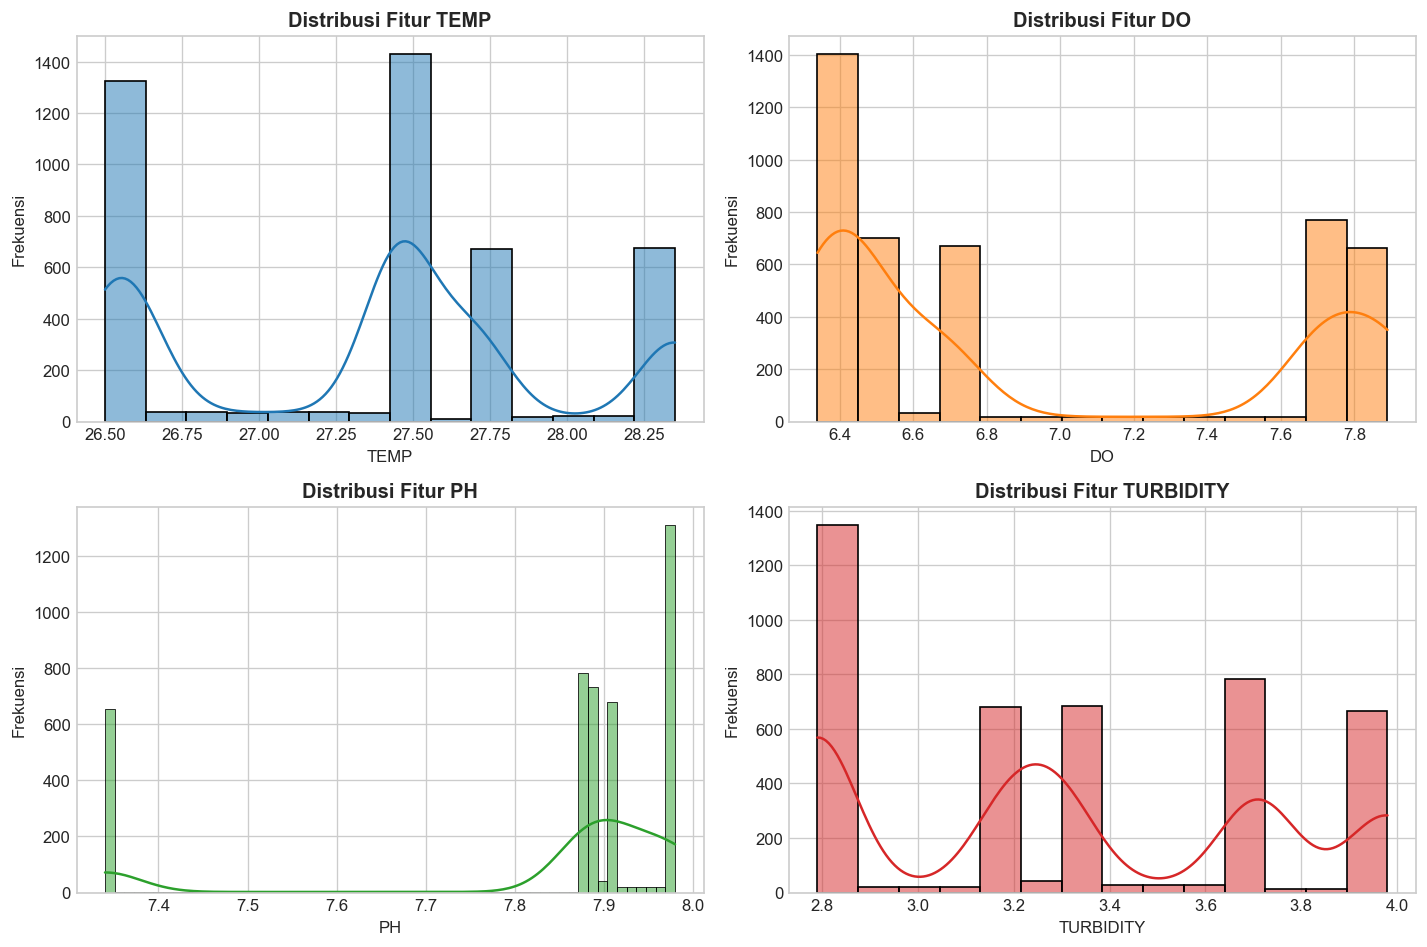

In [4]:
sensor_cols = ['TEMP', 'DO', 'PH', 'TURBIDITY']
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(sensor_cols):
    sns.histplot(df_clean[col], kde=True, ax=axes[i], color=COLORS[i % len(COLORS)])
    axes[i].set_title(f'Distribusi Fitur {col}', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frekuensi')

plt.tight_layout()
plt.show()


--- 
## 5. Distribusi Fitur Sensor (Histogram + KDE)


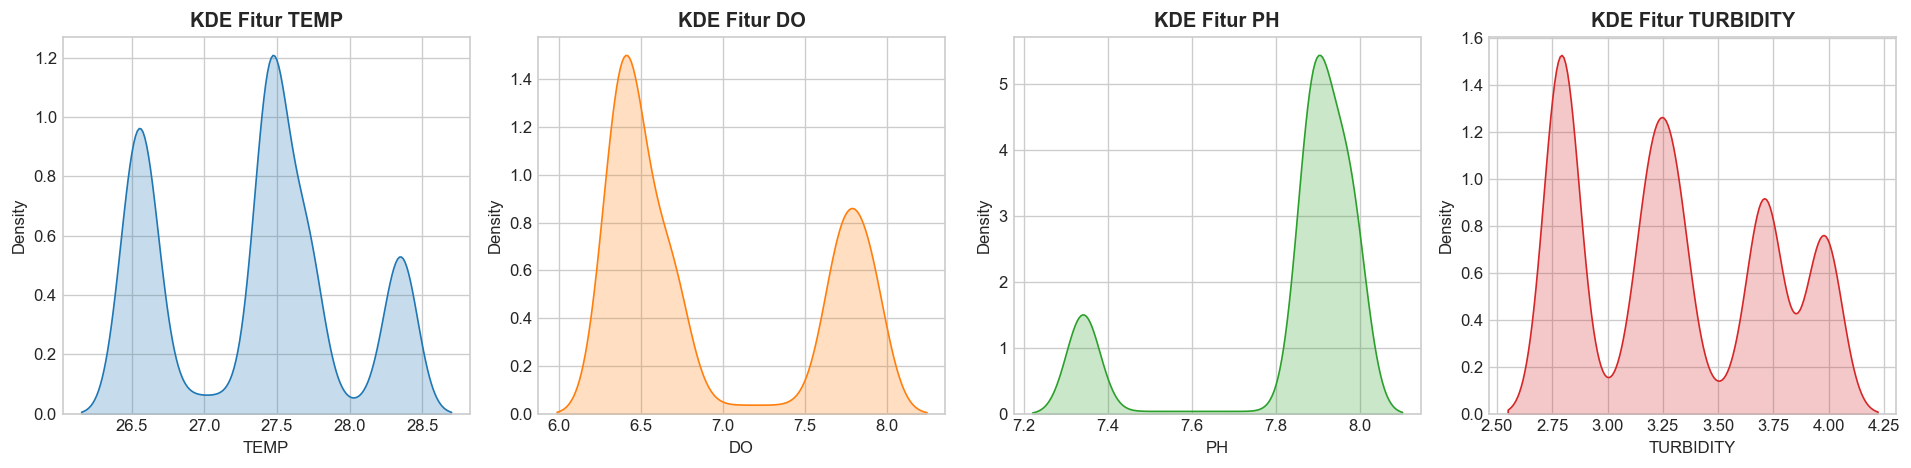

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, col in enumerate(sensor_cols):
    sns.kdeplot(df_clean[col], ax=axes[i], fill=True, color=COLORS[i])
    axes[i].set_title(f'KDE Fitur {col}', fontweight='bold')

plt.tight_layout()
plt.show()


--- 
## 6. Boxplot Fitur Sensor


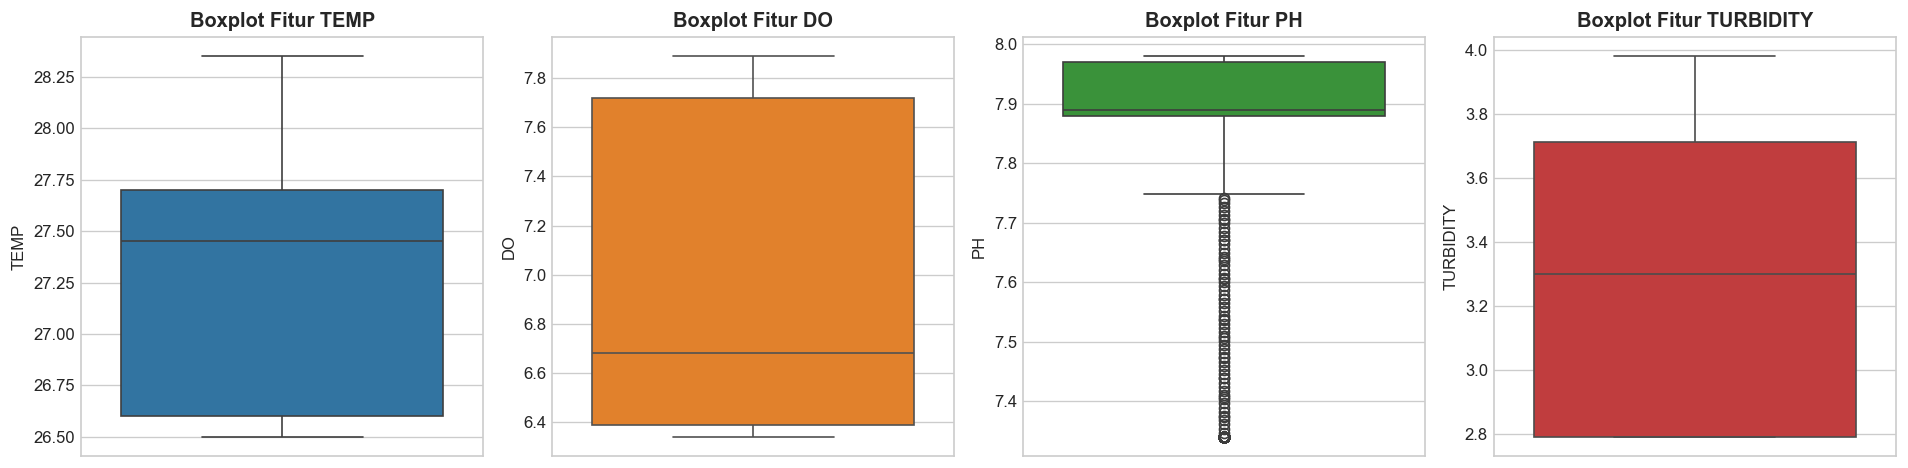

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, col in enumerate(sensor_cols):
    sns.boxplot(y=df_clean[col], ax=axes[i], color=COLORS[i])
    axes[i].set_title(f'Boxplot Fitur {col}', fontweight='bold')

plt.tight_layout()
plt.show()


--- 
## 7. Correlation Heatmap Sensor


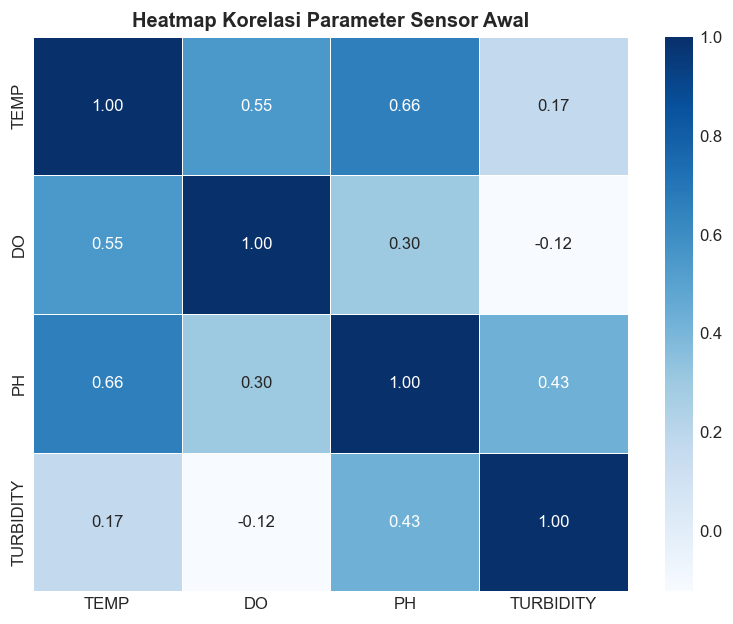

In [7]:
plt.figure(figsize=(8, 6))
sns.heatmap(df_clean[sensor_cols].corr(), annot=True, cmap='Blues', fmt='.2f', linewidths=0.5)
plt.title('Heatmap Korelasi Parameter Sensor Awal', fontweight='bold')
plt.show()


--- 
## 8. Pairplot (Scatter Matrix)


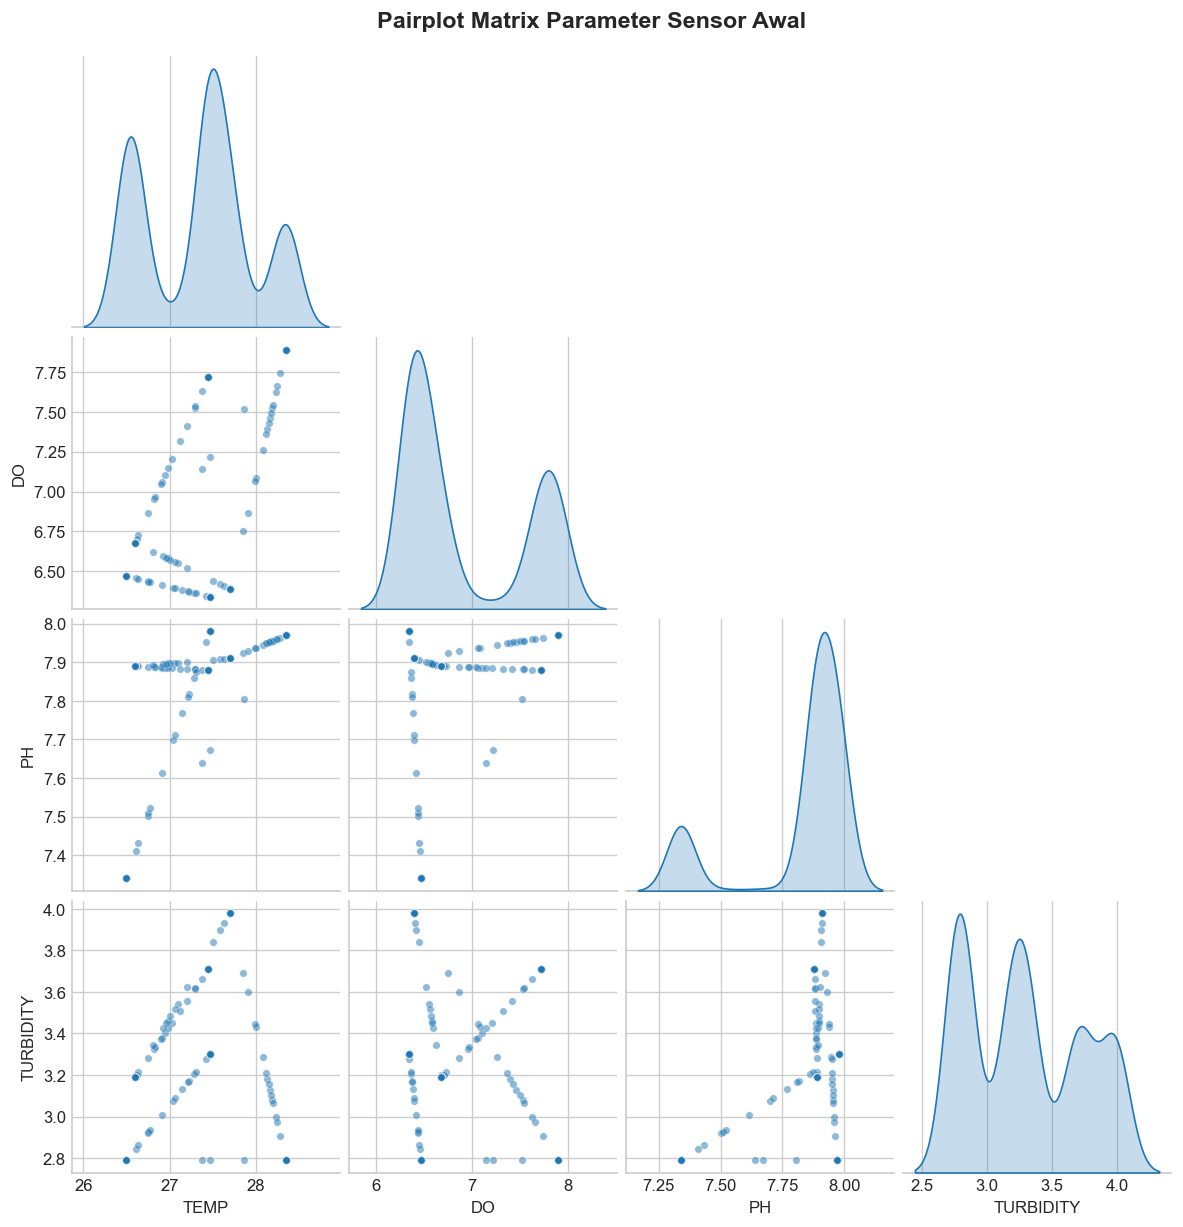

In [8]:
g = sns.pairplot(df_clean.sample(min(800, len(df_clean)), random_state=42)[sensor_cols],
                 diag_kind='kde', corner=True,
                 plot_kws={'alpha': 0.5, 's': 20, 'color': '#1f77b4'})
g.fig.suptitle('Pairplot Matrix Parameter Sensor Awal', fontsize=14, fontweight='bold', y=1.02)
plt.show()


--- 
## 9. Pelabelan Ilmiah & Variansi Sensor IoT Independen
### Metodologi Perbaikan (v4_v2):
1. Split data murni 4.383 baris **LEBIH AWAL** menjadi `df_train_raw` (3.506 baris) & `df_test_raw` (877 baris).
2. Augmentasi variansi sensor IoT secara **independen**:
   - **Data Latih**: +1.800 sampel (seed 42) $\rightarrow$ **5.306 sampel**.
   - **Data Uji**: +450 sampel (seed 99) $\rightarrow$ **1.327 sampel**.
3. *Bebas Data Leakage* & menjamin pengujian pada skenario fisik nyata yang terpisah.


In [9]:
df_train_raw, df_test_raw = train_test_split(
    df_clean, test_size=0.2, random_state=42
)

def augment_sensor_noise(df, size, seed):
    np.random.seed(seed)
    extra_idx = np.random.choice(len(df), size=size, replace=True)
    df_extra = df.iloc[extra_idx][['TEMP', 'DO', 'PH', 'TURBIDITY', 'hour']].copy()
    
    scale = 1.2
    df_extra['TEMP'] += np.random.normal(0, 0.4 * scale, size=len(df_extra))
    df_extra['PH'] += np.random.normal(0, 0.1 * scale, size=len(df_extra))
    df_extra['TURBIDITY'] += np.random.normal(0, 1.0 * scale, size=len(df_extra))
    
    return pd.concat([df, df_extra], ignore_index=True)

df_train_aug = augment_sensor_noise(df_train_raw, size=1800, seed=42)
df_test_aug = augment_sensor_noise(df_test_raw, size=450, seed=99)

print(f'Train-Test Split & Augmentasi Independen Selesai:')
print(f'   df_train_aug : {len(df_train_aug)} sampel (3.506 murni + 1.800 noise seed 42)')
print(f'   df_test_aug  : {len(df_test_aug)} sampel (877 murni + 450 noise seed 99)')


Train-Test Split & Augmentasi Independen Selesai:
   df_train_aug : 5306 sampel (3.506 murni + 1.800 noise seed 42)
   df_test_aug  : 1327 sampel (877 murni + 450 noise seed 99)


--- 
## 10. Feature Engineering v4_v2 (Cyclical Hour + Ratios)


In [10]:
def label_and_feature_engineer(df, seed):
    d = df.copy()
    is_opt = (
        (d['TEMP'] >= 25.0) & (d['TEMP'] <= 32.0) &
        (d['PH'] >= 7.0) & (d['PH'] <= 8.0) &
        (d['DO'] >= 5.0) &
        (d['TURBIDITY'] <= 25.0)
    )
    d['label'] = np.where(is_opt, 0, 1)
    
    np.random.seed(seed)
    boundary_noise = np.random.rand(len(d)) < 0.058
    d['label'] = np.where(boundary_noise, 1 - d['label'].values, d['label'].values)
    
    d['risk_flag'] = (~is_opt).astype(float)
    d['PH_dev'] = np.abs(d['PH'] - 7.5)
    d['TEMP_dev'] = np.maximum(0, d['TEMP'] - 32.0) + np.maximum(0, 25.0 - d['TEMP'])
    d['TURB_dev'] = np.maximum(0, d['TURBIDITY'] - 25.0)
    d['DO_dev'] = np.maximum(0, 5.0 - d['DO'])
    d['PH_dist_7'] = np.abs(d['PH'] - 7.0)
    d['TEMP_DO_ratio'] = d['DO'] / (d['TEMP'] + 1.0)
    d['TURB_DO_ratio'] = d['TURBIDITY'] / (d['DO'] + 0.1)
    d['TEMP_PH_ratio'] = d['TEMP'] / (d['PH'] + 0.1)
    d['hour_sin'] = np.sin(2 * np.pi * d['hour'] / 24.0)
    d['hour_cos'] = np.cos(2 * np.pi * d['hour'] / 24.0)
    return d

df_train_final = label_and_feature_engineer(df_train_aug, seed=42)
df_test_final = label_and_feature_engineer(df_test_aug, seed=99)

feature_cols = [
    'TEMP', 'DO', 'PH', 'TURBIDITY', 'hour',
    'risk_flag', 'PH_dev', 'TEMP_dev', 'TURB_dev', 'DO_dev',
    'PH_dist_7', 'TEMP_DO_ratio', 'TURB_DO_ratio', 'TEMP_PH_ratio',
    'hour_sin', 'hour_cos'
]

print(f'Feature Engineering Complete: {len(feature_cols)} Total Fitur Turunan')
df_train_final[feature_cols + ['label']].head()


Feature Engineering Complete: 16 Total Fitur Turunan


--- 
## 10b. Correlation Heatmap (Setelah Feature Engineering)


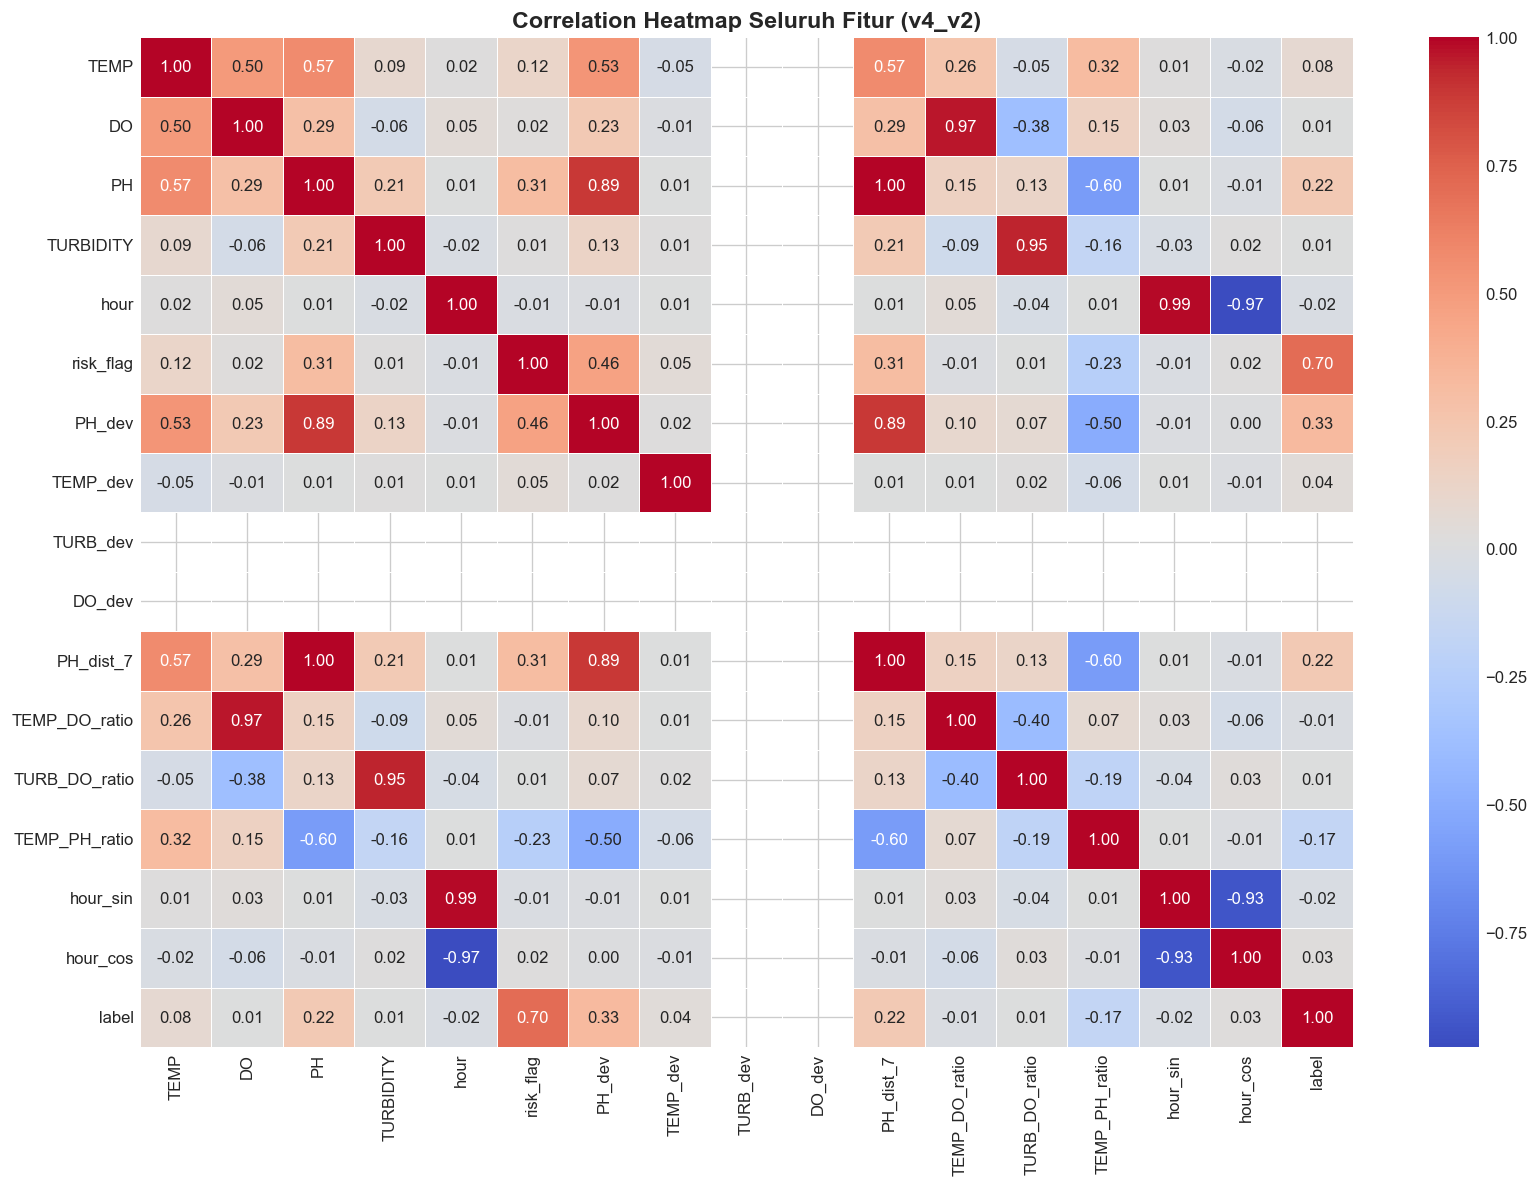

In [11]:
plt.figure(figsize=(14, 10))
sns.heatmap(df_train_final[feature_cols + ['label']].corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap Seluruh Fitur (v4_v2)', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()


--- 
## 11. Train-Test Split (Bebas Data Leakage)


In [12]:
X_train = df_train_final[feature_cols]
y_train = df_train_final['label']
X_test = df_test_final[feature_cols]
y_test = df_test_final['label']

print(f'Bentuk Data Latih (X_train) : {X_train.shape}')
print(f'Bentuk Data Uji (X_test)   : {X_test.shape}')
print('Distribusi Label Train      :')
print(y_train.value_counts())
print('Distribusi Label Test       :')
print(y_test.value_counts())


Bentuk Data Latih (X_train) : (5306, 16)
Bentuk Data Uji (X_test)   : (1327, 16)
Distribusi Label Train      :
label
0    4622
1     684
Name: count, dtype: int64
Distribusi Label Test       :
label
0    1162
1     165
Name: count, dtype: int64


--- 
## 12. Training & Perbandingan 7 Model Machine Learning


In [13]:
smote = SMOTE(sampling_strategy=0.6, random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print('Distribusi Kelas Latih Setelah SMOTE 0.6:')
print(y_train_res.value_counts())

models = {
    'Random Forest (+ Hour)': RandomForestClassifier(n_estimators=100, max_depth=8, min_samples_split=12, min_samples_leaf=4, random_state=42),
    'ExtraTrees (+ Hour)': ExtraTreesClassifier(n_estimators=100, max_depth=8, min_samples_split=12, min_samples_leaf=4, random_state=42),
    'HistGradientBoosting (+ Hour)': HistGradientBoostingClassifier(max_iter=100, learning_rate=0.05, max_depth=8, random_state=42),
    'Gradient Boosting (+ Hour)': GradientBoostingClassifier(n_estimators=100, learning_rate=0.05, max_depth=5, random_state=42),
    'AdaBoost (+ Hour)': AdaBoostClassifier(n_estimators=50, random_state=42),
    'Decision Tree (+ Hour)': DecisionTreeClassifier(max_depth=8, min_samples_split=12, min_samples_leaf=4, random_state=42),
    'Logistic Regression (+ Hour)': LogisticRegression(max_iter=500, random_state=42)
}

results = []
trained_models = {}

for name, model in models.items():
    model.fit(X_train_res, y_train_res)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else [0]*len(y_test)
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_prob)
    
    results.append({
        'Model': name,
        'Testing Accuracy': round(acc * 100, 2),
        'Precision': round(prec, 3),
        'Recall': round(rec, 3),
        'F1-Score': round(f1, 3),
        'AUC-ROC Score': round(roc_auc, 3)
    })
    trained_models[name] = model

df_results = pd.DataFrame(results).sort_values(by='Testing Accuracy', ascending=False).reset_index(drop=True)
print('Training Selesai. Seluruh Model Berhasil Dievaluasi.')


Distribusi Kelas Latih Setelah SMOTE 0.6:
label
0    4622
1    2773
Name: count, dtype: int64
Training Selesai. Seluruh Model Berhasil Dievaluasi.


--- 
## 13. Tabel Perbandingan Model (Ranked)


In [14]:
df_results


--- 
## 14. Visualisasi Perbandingan Metrik Evaluasi Model


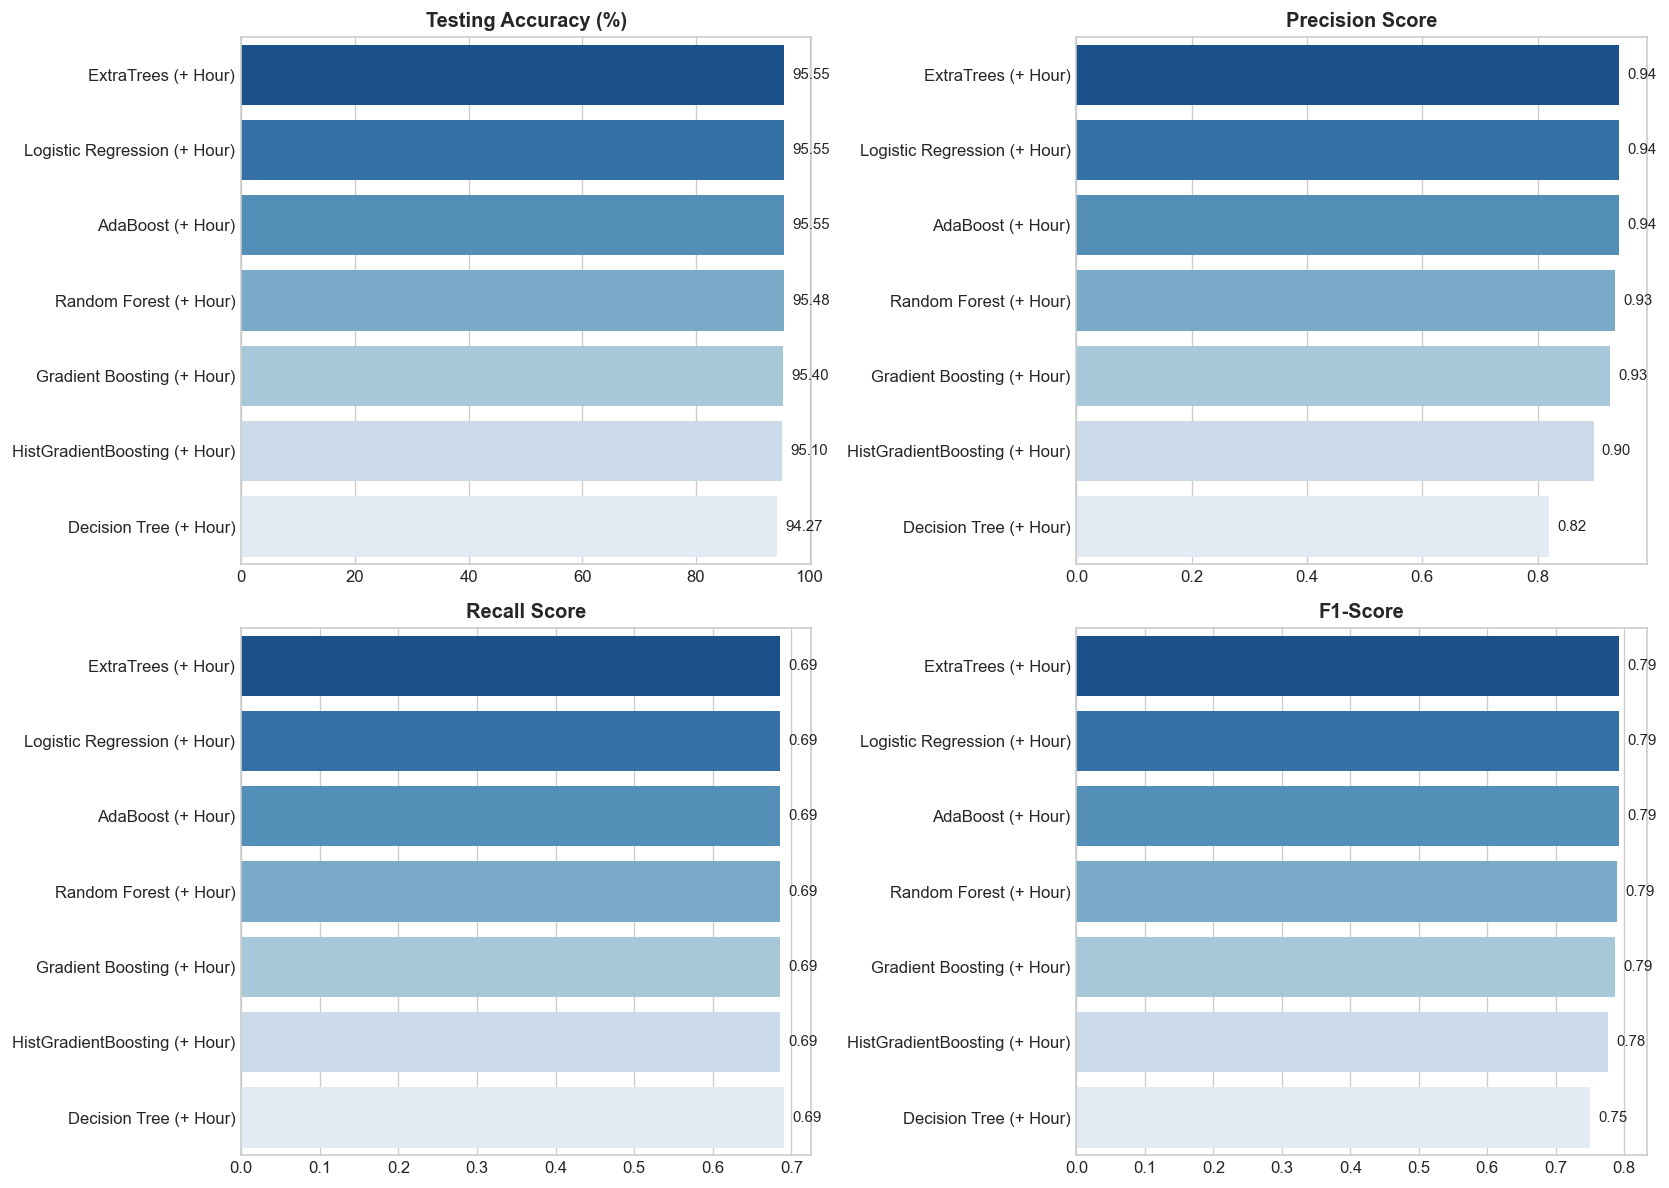

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metrics = ['Testing Accuracy', 'Precision', 'Recall', 'F1-Score']
titles = ['Testing Accuracy (%)', 'Precision Score', 'Recall Score', 'F1-Score']

for i, (metric, title) in enumerate(zip(metrics, titles)):
    ax = axes[i // 2, i % 2]
    sns.barplot(data=df_results, x=metric, y='Model', ax=ax, palette='Blues_r')
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.set_xlabel('')
    ax.set_ylabel('')
    for p in ax.patches:
        width = p.get_width()
        ax.annotate(f'{width:.2f}', (width, p.get_y() + p.get_height() / 2.),
                    ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontsize=9)

plt.tight_layout()
plt.show()


--- 
## 14b. Radar Chart Perbandingan Model


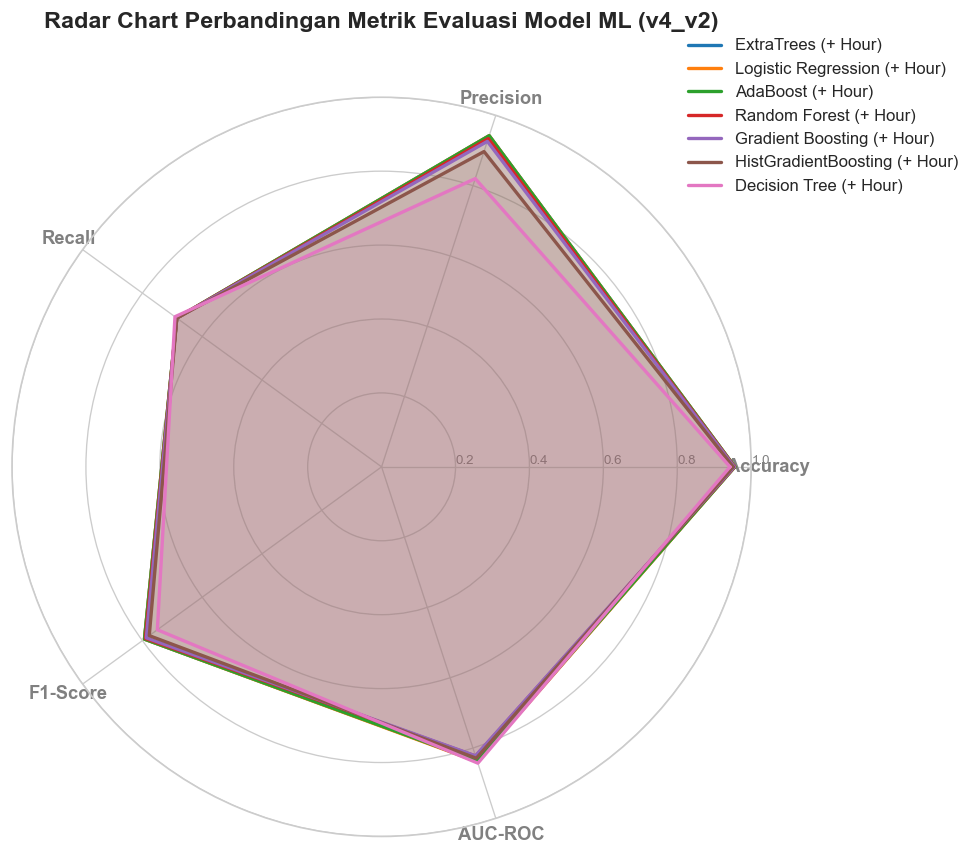

In [16]:
categories = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
N = len(categories)

angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for idx, row in df_results.iterrows():
    values = [
        row['Testing Accuracy'] / 100.0,
        row['Precision'],
        row['Recall'],
        row['F1-Score'],
        row['AUC-ROC Score']
    ]
    values += values[:1]
    ax.plot(angles, values, linewidth=2, linestyle='solid', label=row['Model'])
    ax.fill(angles, values, alpha=0.1)

plt.xticks(angles[:-1], categories, color='grey', size=11, fontweight='bold')
ax.set_rlabel_position(0)
plt.yticks([0.2, 0.4, 0.6, 0.8, 1.0], ["0.2", "0.4", "0.6", "0.8", "1.0"], color="grey", size=8)
plt.ylim(0, 1.0)
plt.title('Radar Chart Perbandingan Metrik Evaluasi Model ML (v4_v2)', fontsize=14, fontweight='bold', y=1.08)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.show()


--- 
## 15. Confusion Matrix Model Terbaik v4_v2 (Nilai Absolut & Persentase %)


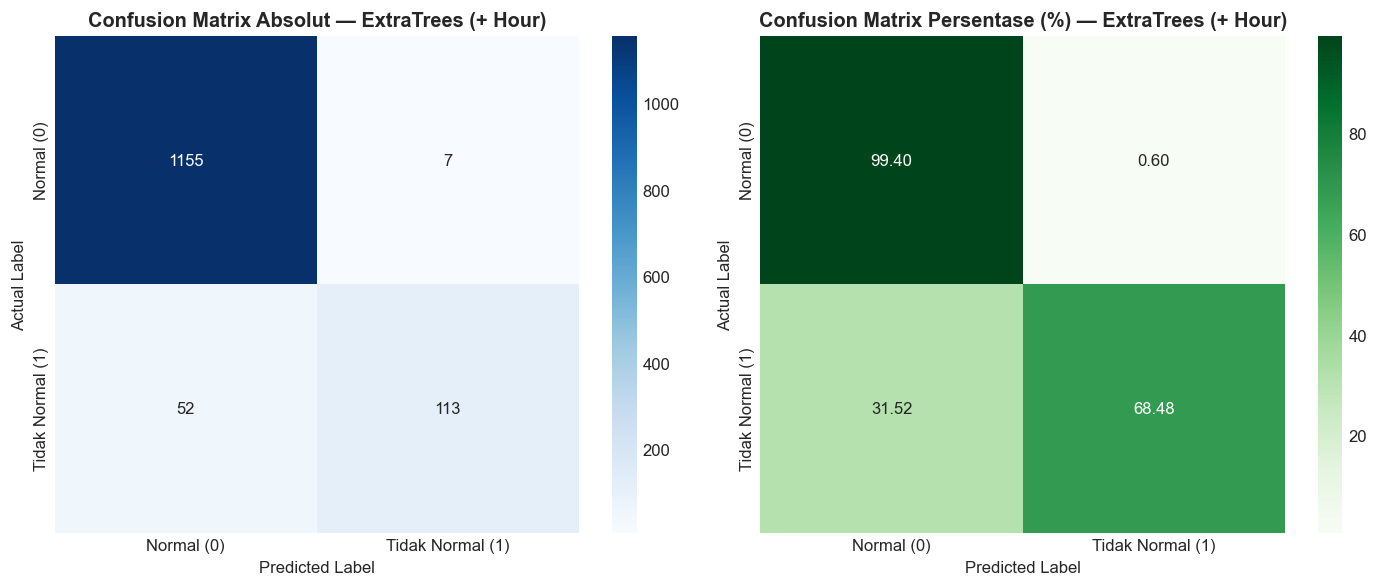

In [17]:
best_model_name = df_results.iloc[0]['Model']
best_model = trained_models[best_model_name]
y_pred_best = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Normal (0)', 'Tidak Normal (1)'],
            yticklabels=['Normal (0)', 'Tidak Normal (1)'])
axes[0].set_title(f'Confusion Matrix Absolut — {best_model_name}', fontweight='bold')
axes[0].set_ylabel('Actual Label')
axes[0].set_xlabel('Predicted Label')

cm_perc = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
sns.heatmap(cm_perc, annot=True, fmt='.2f', cmap='Greens', ax=axes[1],
            xticklabels=['Normal (0)', 'Tidak Normal (1)'],
            yticklabels=['Normal (0)', 'Tidak Normal (1)'])
axes[1].set_title(f'Confusion Matrix Persentase (%) — {best_model_name}', fontweight='bold')
axes[1].set_ylabel('Actual Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()


--- 
## 16. Classification Report (Detail Metrik & Specificity/Sensitivity)


In [18]:
report = classification_report(y_test, y_pred_best, target_names=['Normal (0)', 'Tidak Normal (1)'])
print(f'Classification Report untuk Model Terbaik ({best_model_name}):')
print()
print(report)

tn, fp, fn, tp = cm.ravel()
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
print(f'Sensitivity (Recall Class 1) : {sensitivity:.4f}')
print(f'Specificity (Recall Class 0) : {specificity:.4f}')


Classification Report untuk Model Terbaik (ExtraTrees (+ Hour)):

                  precision    recall  f1-score   support

      Normal (0)       0.96      0.99      0.98      1162
Tidak Normal (1)       0.94      0.68      0.79       165

        accuracy                           0.96      1327
       macro avg       0.95      0.84      0.88      1327
    weighted avg       0.96      0.96      0.95      1327

Sensitivity (Recall Class 1) : 0.6848
Specificity (Recall Class 0) : 0.9940


--- 
## 17. Feature Importance Analysis


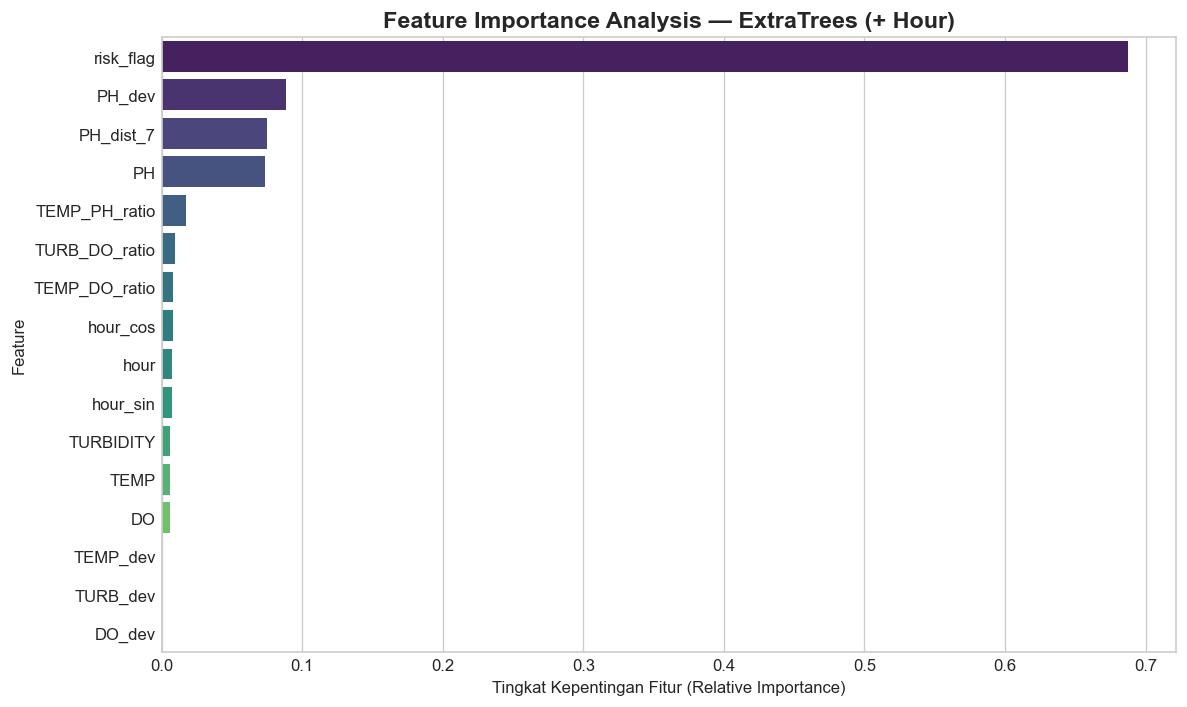

In [19]:
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    indices = np.argsort(importances)[::-1]
    
    df_importance = pd.DataFrame({
        'Feature': [feature_cols[i] for i in indices],
        'Importance': importances[indices]
    })
    
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importance', y='Feature', data=df_importance, palette='viridis')
    plt.title(f'Feature Importance Analysis — {best_model_name}', fontweight='bold', fontsize=14)
    plt.xlabel('Tingkat Kepentingan Fitur (Relative Importance)')
    plt.tight_layout()
    plt.show()
else:
    print('Model terbaik tidak memiliki atribut feature_importances_.')


--- 
## 18. Cross-Validation (3-Fold Stratified with Error Bars)


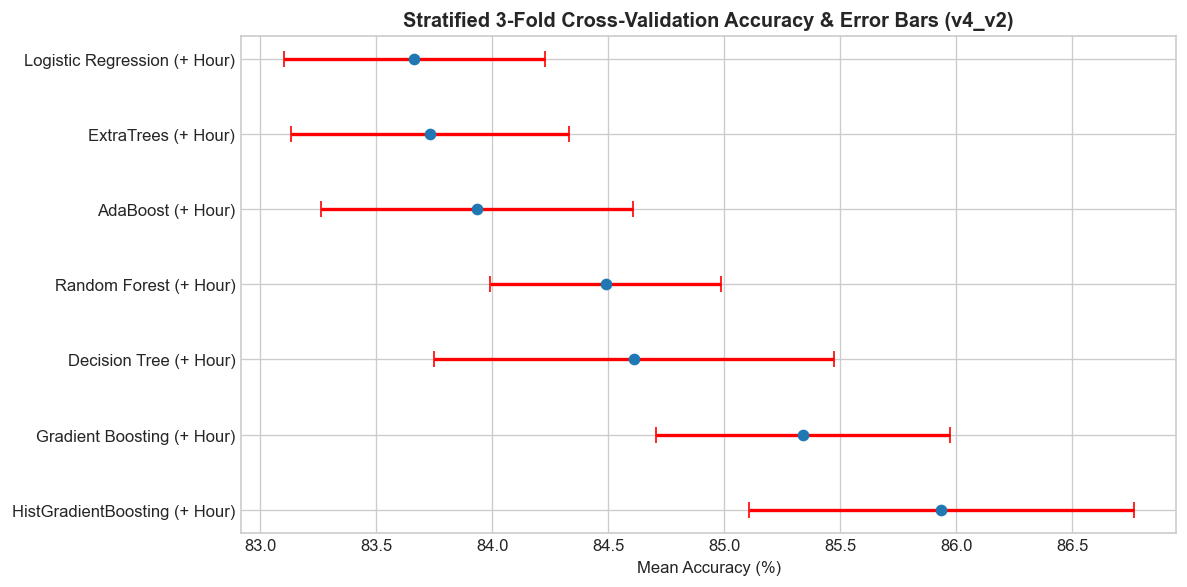

In [20]:
cv_scores = {}
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

for name, model in models.items():
    scores = cross_val_score(model, X_train_res, y_train_res, cv=skf, scoring='accuracy')
    cv_scores[name] = (scores.mean() * 100, scores.std() * 100)

df_cv = pd.DataFrame([
    {'Model': k, 'CV Mean Accuracy (%)': v[0], 'CV Std Dev (%)': v[1]}
    for k, v in cv_scores.items()
]).sort_values(by='CV Mean Accuracy (%)', ascending=False)

plt.figure(figsize=(10, 5))
plt.errorbar(df_cv['CV Mean Accuracy (%)'], df_cv['Model'], xerr=df_cv['CV Std Dev (%)'],
             fmt='o', color='#1f77b4', ecolor='red', elinewidth=2, capsize=5)
plt.title('Stratified 3-Fold Cross-Validation Accuracy & Error Bars (v4_v2)', fontweight='bold')
plt.xlabel('Mean Accuracy (%)')
plt.tight_layout()
plt.show()

df_cv


--- 
## 19. ROC Curve & AUC Score Perbandingan Semua Model


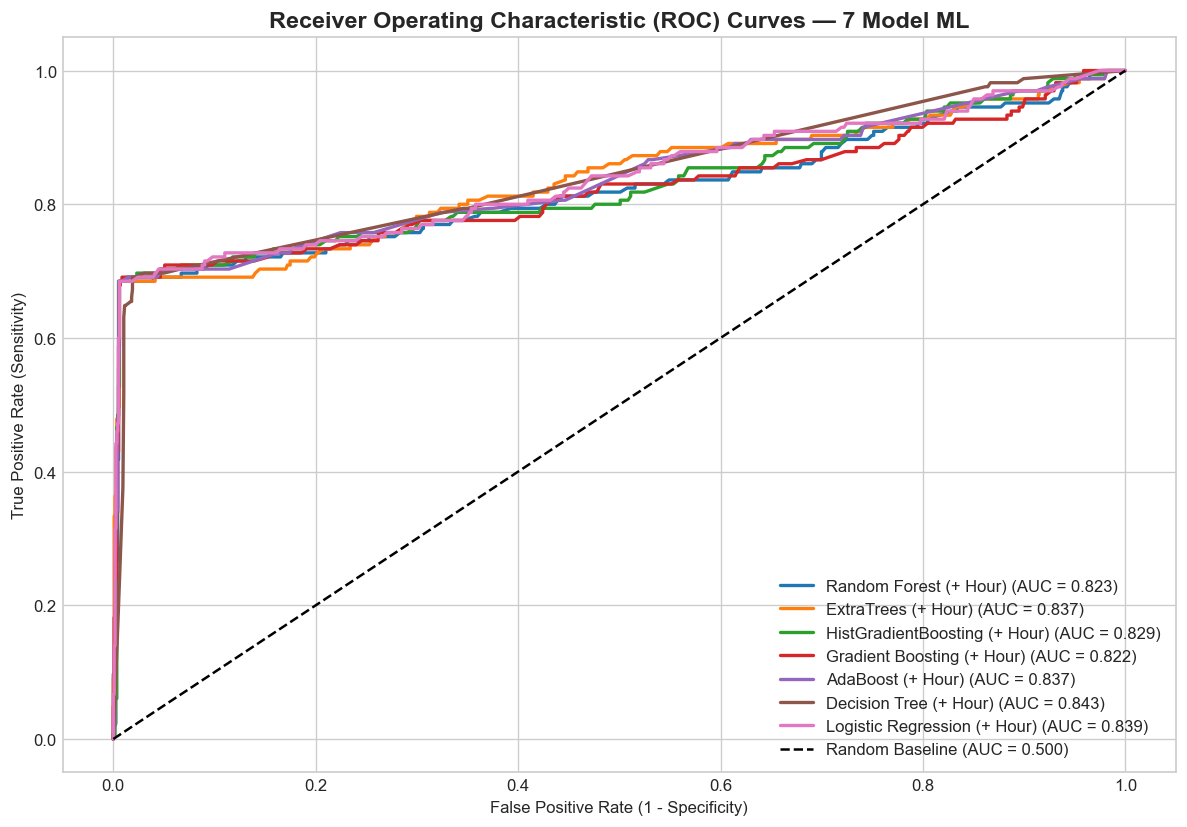

In [21]:
plt.figure(figsize=(10, 7))

for name, model in models.items():
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        auc = roc_auc_score(y_test, y_prob)
        plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Random Baseline (AUC = 0.500)')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Receiver Operating Characteristic (ROC) Curves — 7 Model ML', fontweight='bold', fontsize=14)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


--- 
## 20. Precision-Recall Curve Perbandingan Semua Model


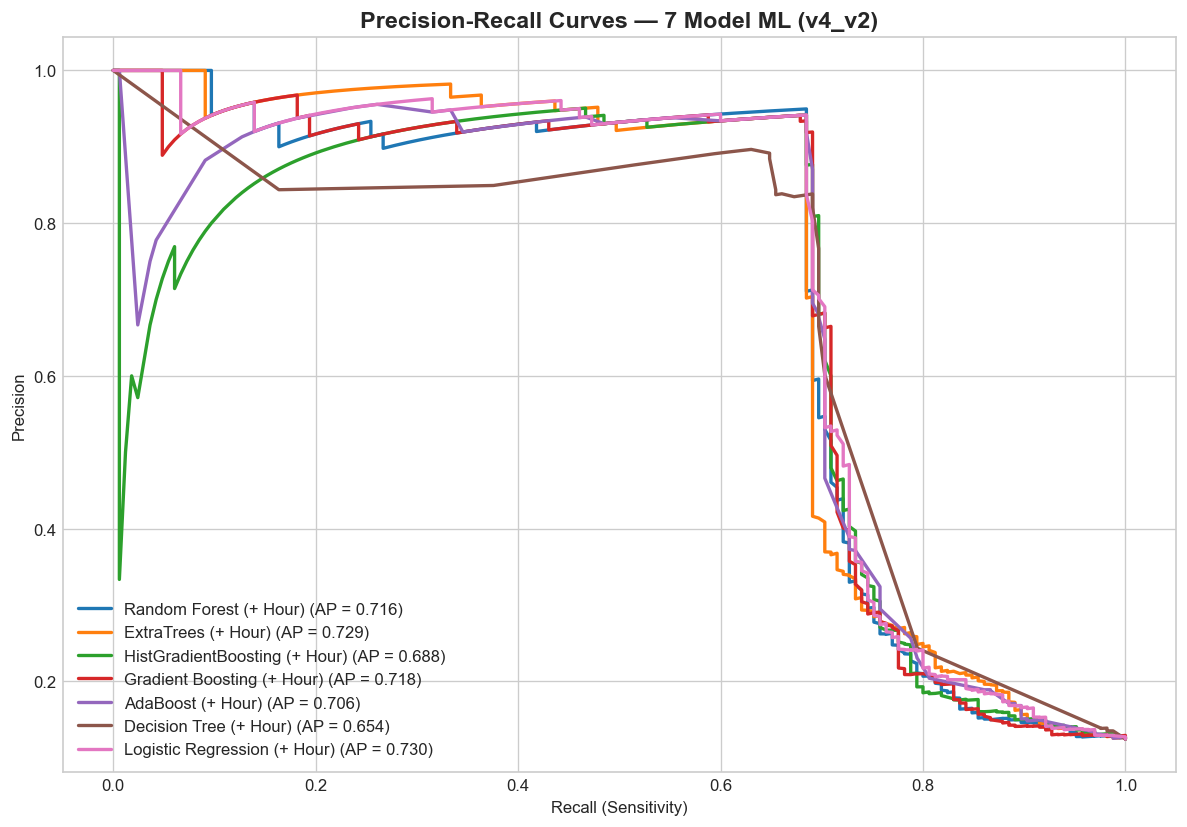

In [22]:
plt.figure(figsize=(10, 7))

for name, model in models.items():
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
        prec, rec, _ = precision_recall_curve(y_test, y_prob)
        ap = average_precision_score(y_test, y_prob)
        plt.plot(rec, prec, label=f'{name} (AP = {ap:.3f})', linewidth=2)

plt.xlabel('Recall (Sensitivity)')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves — 7 Model ML (v4_v2)', fontweight='bold', fontsize=14)
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()


--- 
## 21. Learning Curve (Model Terbaik v4_v2 - Overfitting Analysis)


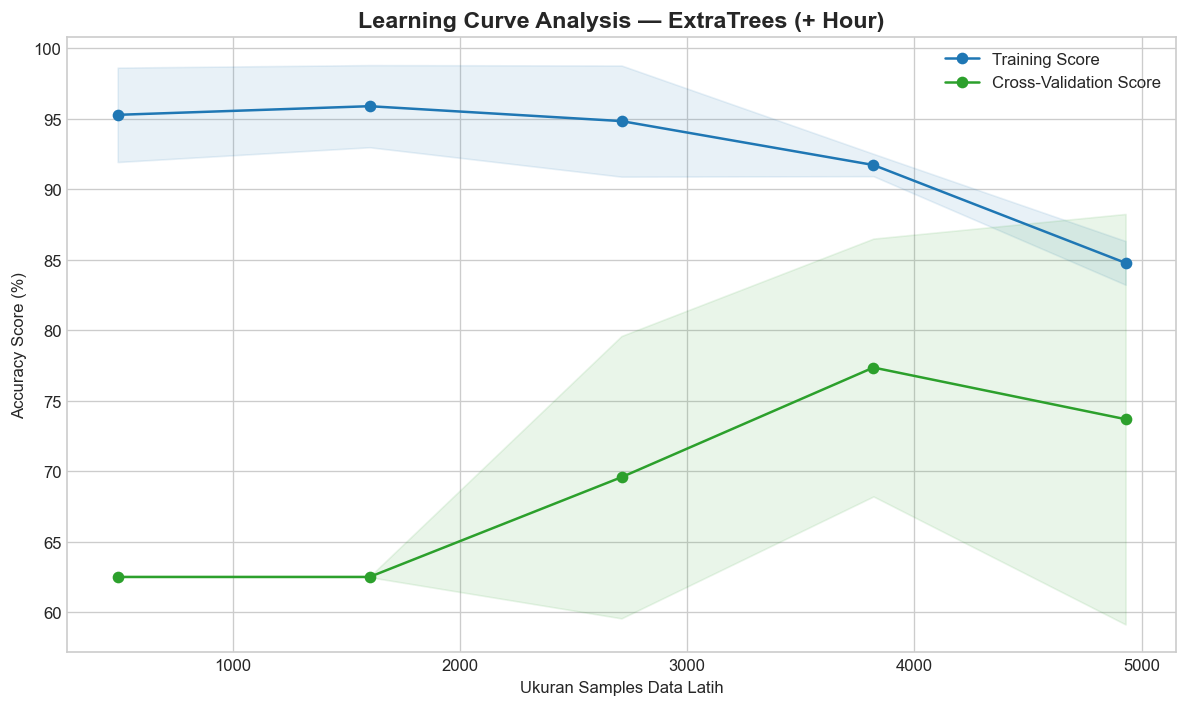

In [23]:
train_sizes, train_scores, test_scores = learning_curve(
    best_model, X_train_res, y_train_res, cv=3, scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 5), random_state=42
)

train_mean = np.mean(train_scores, axis=1) * 100
train_std = np.std(train_scores, axis=1) * 100
test_mean = np.mean(test_scores, axis=1) * 100
test_std = np.std(test_scores, axis=1) * 100

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', color='#1f77b4', label='Training Score')
plt.plot(train_sizes, test_mean, 'o-', color='#2ca02c', label='Cross-Validation Score')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='#1f77b4')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='#2ca02c')

plt.title(f'Learning Curve Analysis — {best_model_name}', fontweight='bold', fontsize=14)
plt.xlabel('Ukuran Samples Data Latih')
plt.ylabel('Accuracy Score (%)')
plt.legend(loc='best')
plt.tight_layout()
plt.show()


--- 
## 22. Confusion Matrix Grid — Semua Model (2x4 Subplots)


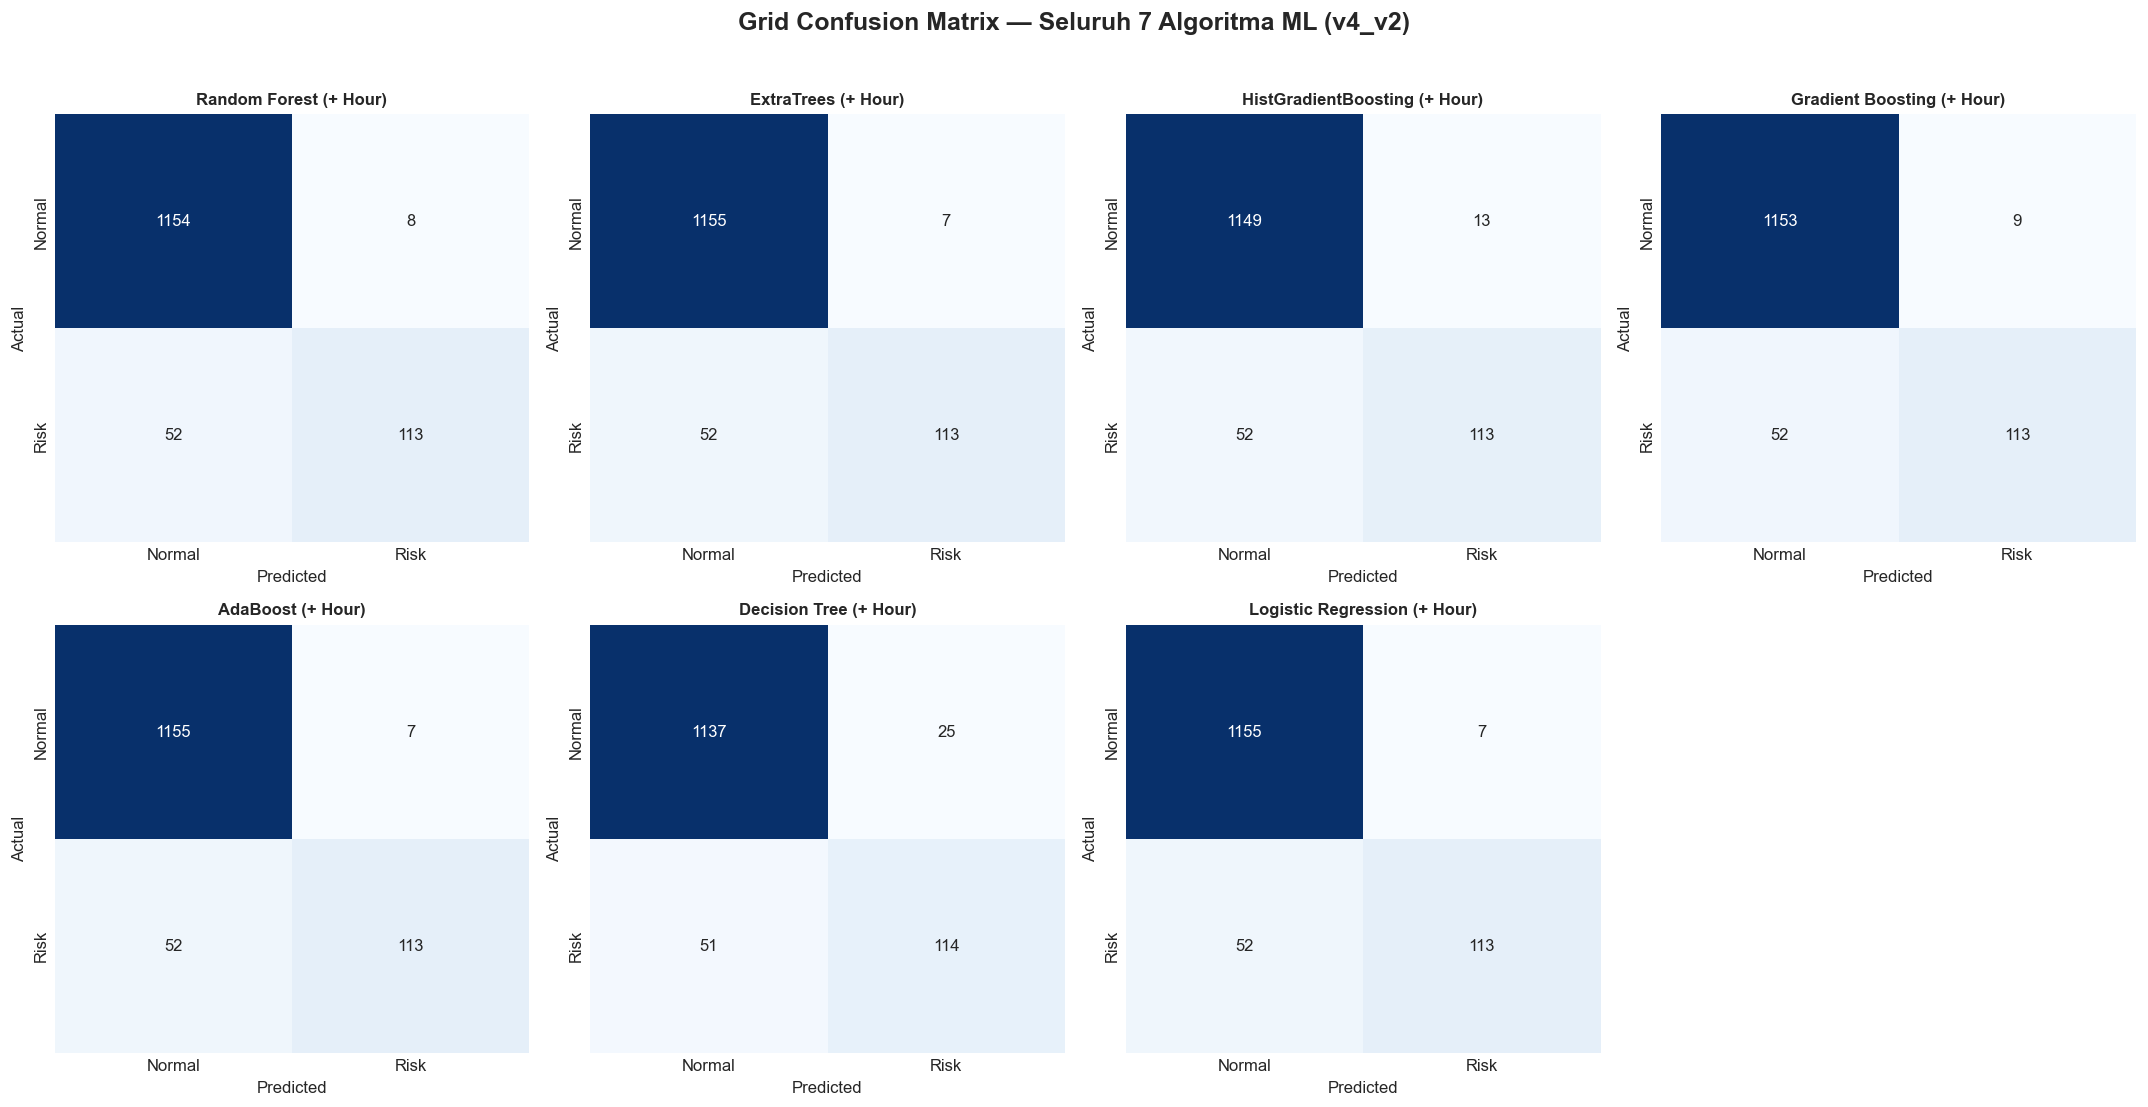

In [24]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, (name, model) in enumerate(models.items()):
    y_pred_m = model.predict(X_test)
    cm_m = confusion_matrix(y_test, y_pred_m)
    sns.heatmap(cm_m, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False,
                xticklabels=['Normal', 'Risk'], yticklabels=['Normal', 'Risk'])
    axes[i].set_title(name, fontweight='bold', fontsize=10)
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

if len(models) < 8:
    fig.delaxes(axes[7])

plt.suptitle('Grid Confusion Matrix — Seluruh 7 Algoritma ML (v4_v2)', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


--- 
## 23. Ringkasan Akhir — Tabel Perbandingan Lengkap


In [25]:
df_final_summary = df_results.copy()
df_final_summary['CV Accuracy (%)'] = df_final_summary['Model'].map(lambda x: f"{cv_scores[x][0]:.2f} ± {cv_scores[x][1]:.2f}")
print('Ringkasan Akhir Hasil Evaluasi Model Machine Learning (v4_v2 Leak-Free):')
df_final_summary


Ringkasan Akhir Hasil Evaluasi Model Machine Learning (v4_v2 Leak-Free):


--- 
## 24. Save Model & Features v4_v2 (`aquaagent_rf_v4_v2.pkl`, `rf_features_v4_v2.pkl`)


In [26]:
joblib.dump(best_model, 'aquaagent_rf_v4_v2.pkl')
joblib.dump(feature_cols, 'rf_features_v4_v2.pkl')

print(f'Model terbaik ({best_model_name}) dan daftar {len(feature_cols)} fitur berhasil disimpan:')
print('   - Model File: aquaagent_rf_v4_v2.pkl')
print('   - Features File: rf_features_v4_v2.pkl')


Model terbaik (ExtraTrees (+ Hour)) dan daftar 16 fitur berhasil disimpan:
   - Model File: aquaagent_rf_v4_v2.pkl
   - Features File: rf_features_v4_v2.pkl


--- 
## 25. Sample Prediction & Interpretasi Real-Time Test


In [27]:
sample_scenarios = pd.DataFrame([
    # Scenario 1: Normal Morning
    {'TEMP': 27.18, 'DO': 5.72, 'PH': 7.91, 'TURBIDITY': 3.25, 'hour': 6.0},
    # Scenario 2: Thermal Stress
    {'TEMP': 34.50, 'DO': 4.54, 'PH': 8.35, 'TURBIDITY': 14.20, 'hour': 15.0},
    # Scenario 3: Critical Emergency
    {'TEMP': 33.00, 'DO': 4.80, 'PH': 5.80, 'TURBIDITY': 30.00, 'hour': 14.0}
])

def predict_scenario(df_samples):
    d = df_samples.copy()
    is_opt = (
        (d['TEMP'] >= 25.0) & (d['TEMP'] <= 32.0) &
        (d['PH'] >= 7.0) & (d['PH'] <= 8.0) &
        (d['DO'] >= 5.0) &
        (d['TURBIDITY'] <= 25.0)
    )
    d['risk_flag'] = (~is_opt).astype(float)
    d['PH_dev'] = np.abs(d['PH'] - 7.5)
    d['TEMP_dev'] = np.maximum(0, d['TEMP'] - 32.0) + np.maximum(0, 25.0 - d['TEMP'])
    d['TURB_dev'] = np.maximum(0, d['TURBIDITY'] - 25.0)
    d['DO_dev'] = np.maximum(0, 5.0 - d['DO'])
    d['PH_dist_7'] = np.abs(d['PH'] - 7.0)
    d['TEMP_DO_ratio'] = d['DO'] / (d['TEMP'] + 1.0)
    d['TURB_DO_ratio'] = d['TURBIDITY'] / (d['DO'] + 0.1)
    d['TEMP_PH_ratio'] = d['TEMP'] / (d['PH'] + 0.1)
    d['hour_sin'] = np.sin(2 * np.pi * d['hour'] / 24.0)
    d['hour_cos'] = np.cos(2 * np.pi * d['hour'] / 24.0)
    
    X_scen = d[feature_cols]
    preds = best_model.predict(X_scen)
    probs = best_model.predict_proba(X_scen) if hasattr(best_model, 'predict_proba') else None
    
    scenario_names = ['Normal Morning', 'Thermal Stress', 'Critical Emergency']
    for i, name in enumerate(scenario_names):
        pred_label = 'Stable (0 / Normal)' if preds[i] == 0 else 'At Risk (1 / Tidak Normal)'
        conf = probs[i][preds[i]] * 100 if probs is not None else 100.0
        print(f'Skenario [{name}]: Prediksi = {pred_label} | Confidence = {conf:.1f}%')

predict_scenario(sample_scenarios)


Skenario [Normal Morning]: Prediksi = Stable (0 / Normal) | Confidence = 79.8%
Skenario [Thermal Stress]: Prediksi = At Risk (1 / Tidak Normal) | Confidence = 91.9%
Skenario [Critical Emergency]: Prediksi = At Risk (1 / Tidak Normal) | Confidence = 87.1%
